In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import keras
from keras import layers, regularizers
layers = keras.layers

In [6]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



In [7]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


In [8]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = keras.utils.to_categorical(y_test, 10)[8000:]

In [ ]:
# 1. Define the Residual Block
def residual_block(x, filters, strides=1):
    shortcut = x
    
    # If dimensions change, adjust the shortcut path to match
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=strides, use_bias=False, 
                                 kernel_regularizer=regularizers.l2(5e-4))(x)
        shortcut = layers.BatchNormalization()(shortcut)

    # First convolution in the block
    x = layers.Conv2D(filters, kernel_size=3, strides=strides, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Second convolution
    x = layers.Conv2D(filters, kernel_size=3, strides=1, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)

    # Add the shortcut to the main path, then activate
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

# 2. Build the Model Architecture
def build_cifar_resnet18(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    
    # --- DATA AUGMENTATION ---
    # Randomly shifts the image by up to 12.5% (4 pixels) to mimic padding/cropping
    x = layers.RandomTranslation(height_factor=0.125, width_factor=0.125, fill_mode="constant")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    
    # --- NORMALIZATION ---
    # Scales images using CIFAR-10 specific means and variances
    x = layers.Normalization(
        mean=[0.4914, 0.4822, 0.4465], 
        variance=[0.0409, 0.0397, 0.0404] # Keras uses variance (Standard Deviation squared)
    )(x)

    # --- CRITICAL CIFAR MODIFICATION ---
    # 3x3 kernel, stride 1, and NO MaxPool layer so the image doesn't shrink too fast
    x = layers.Conv2D(64, kernel_size=3, strides=1, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # --- STACK RESIDUAL BLOCKS --- 
    x = residual_block(x, filters=64, strides=1)
    x = residual_block(x, filters=64, strides=1)
    
    x = residual_block(x, filters=128, strides=2)
    x = residual_block(x, filters=128, strides=1)
    
    x = residual_block(x, filters=256, strides=2)
    x = residual_block(x, filters=256, strides=1)
    
    x = residual_block(x, filters=512, strides=2)
    x = residual_block(x, filters=512, strides=1)

    # --- FINAL CLASSIFICATION HEAD ---
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, kernel_regularizer=regularizers.l2(5e-4))(x)

    return keras.Model(inputs, outputs)

model = build_cifar_resnet18()

2026-06-05 15:25:02.683922: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-06-05 15:25:02.683948: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-05 15:25:02.683972: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1780665902.683986  511388 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780665902.684004  511388 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
# VGG Net
def build_cifar_vgg(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    
    # --- DATA AUGMENTATION ---
    x = layers.RandomTranslation(height_factor=0.125, width_factor=0.125, fill_mode="constant")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    
    # --- NORMALIZATION ---
    x = layers.Normalization(
        mean=[0.4914, 0.4822, 0.4465], 
        variance=[0.0409, 0.0397, 0.0404]
    )(x)

    # --- VGG-STYLE CONVOLUTIONAL BLOCKS ---
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 16x16

    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 8x8

    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 4x4

    # --- FINAL CLASSIFICATION HEAD ---
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_regularizer=regularizers.l2(5e-4))(x)

    return keras.Model(inputs, outputs)

In [10]:
epochs = 200
batch_size = 128
steps_per_epoch = 50000 // batch_size  # 50,000 CIFAR-10 training images

# Slowly decay the learning rate following a cosine curve
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1,
    decay_steps=epochs * steps_per_epoch
)

# SGD with Momentum pairs best with Cosine Annealing
optimizer = keras.optimizers.SGD(
    learning_rate=lr_schedule, 
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [11]:
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

Epoch 1/200


2026-06-05 15:25:53.944677: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


391/391 ━━━━━━━━━━━━━━━━━━━━ 108s 260ms/step - accuracy: 0.3033 - loss: 4.2832 - val_accuracy: 0.3199 - val_loss: 3.4314
Epoch 2/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 102s 261ms/step - accuracy: 0.4445 - loss: 2.6091 - val_accuracy: 0.4340 - val_loss: 2.3565
Epoch 3/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 103s 262ms/step - accuracy: 0.5318 - loss: 1.9041 - val_accuracy: 0.4872 - val_loss: 1.9261
Epoch 4/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 100s 257ms/step - accuracy: 0.6164 - loss: 1.5130 - val_accuracy: 0.5675 - val_loss: 1.7980
Epoch 5/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 100s 256ms/step - accuracy: 0.6821 - loss: 1.2820 - val_accuracy: 0.6031 - val_loss: 1.6247
Epoch 6/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 259ms/step - accuracy: 0.7244 - loss: 1.1654 - val_accuracy: 0.6698 - val_loss: 1.3683
Epoch 7/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 258ms/step - accuracy: 0.7497 - loss: 1.0908 - val_accuracy: 0.7044 - val_loss: 1.2299
Epoch 8/200
391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 259ms/step - accuracy: 0.7691 - los

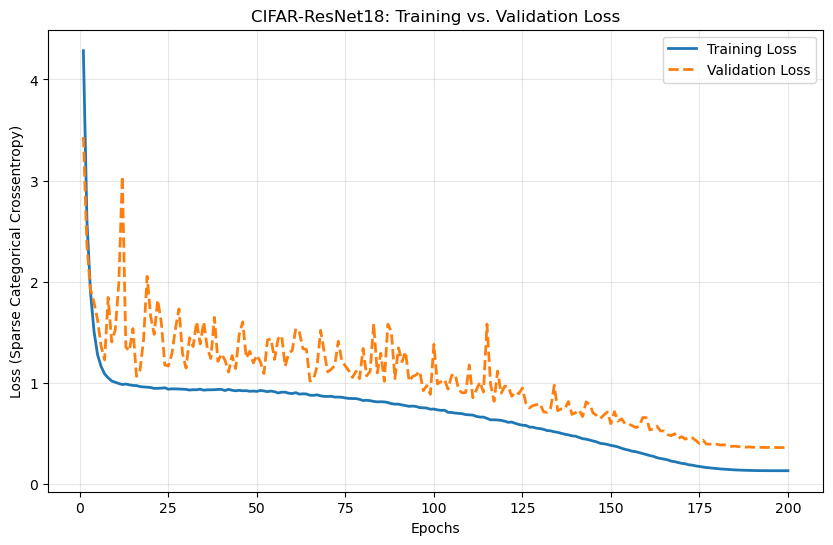

In [12]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(epochs, loss, label='Training Loss', linewidth=2, linestyle='-')
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('CIFAR-ResNet18: Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Sparse Categorical Crossentropy)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


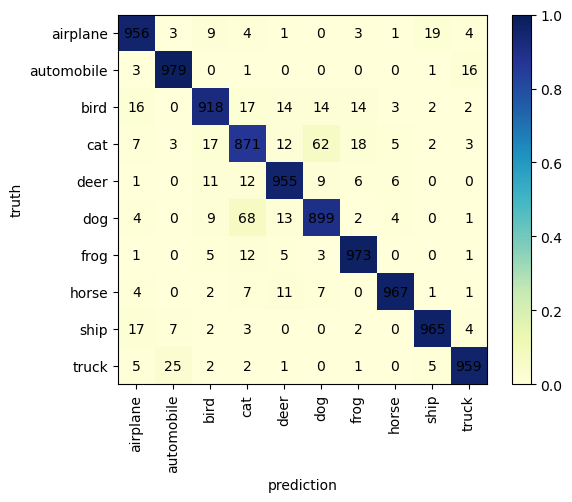

In [15]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate predictions
# Note: Because we used from_logits=True, these are raw scores, not percentages. 
# However, np.argmax still works perfectly because the highest score = the chosen class.
y_predict = model.predict(x_test, batch_size=batch_size)
y_predict_cl = np.argmax(y_predict, axis=1)

# 2. Format the actual test labels
# CIFAR-10 y_test is shaped (10000, 1). We use flatten() to make it a 1D array of (10000,)
# so it matches the shape of y_predict_cl perfectly.
y_test_cl = y_test.flatten()

# 3. Generate the Confusion Matrix
cm = plot_confusion(y_test_cl, y_predict_cl)